In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import random

In [32]:
def f(x):
    return 5*x**2


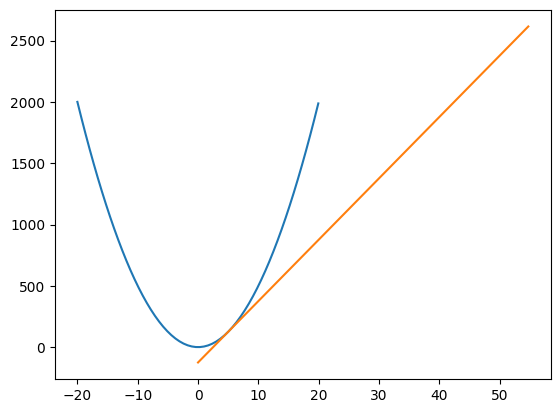

In [33]:
xs = np.arange(-20,20 , 0.6769)
ys=f(xs)
plt.plot(xs,ys)
x=5
h=0.01
diff = (f(x+h)-f(x))/h
x1s=np.arange(x-5, x+50 , 0.25)
y1s=f(x)+diff*(x1s-x)
plt.plot(x1s,y1s)

In [3]:
class value:
    def __init__(self , data , __children=() , _oper='' , label=''):
        self.data = data
        self._prev = set(__children)
        self._op = _oper
        self.label = label
        self.grad = 0.0
        self._backward = lambda : None
        

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other , value ) else value(other)
        out =value(self.data + other.data , (self,other) , '+')
        def _backward():
            self.grad += out.grad*1.0
            other.grad += out.grad*1.0
        out._backward=_backward

        return out
    
    def __radd__(self, other):
        out = self+other
        return out
    def __mul__(self, other):
        other = other if isinstance(other , value ) else value(other)
        out =value((self.data)*(other.data) , (self,other) , '*')

        def _backward():
            self.grad += out.grad*other.data
            other.grad += out.grad*self.data
        out._backward=_backward

        return out


    def __rmul__(self, other):
        return (self*other)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward   

        return out
    

    def __sub__(self, other): # self - other
        return self + (-other)
    
    def __neg__(self): # -self
        return self * -1


    def tanh(self):
        val = math.tanh(self.data)
        out = (value(val  ,(self,), 'tanh'))
        def _backward():
            self.grad += (1-(out.data**2))*out.grad
        out._backward = _backward
        return out
    
    def backward(self):
    
        topo=[]
        visited = set()
        def build_topo(x):
            if x not in visited:
                visited.add(x)
                for child in x._prev:
                    build_topo(child)
                topo.append(x)
        
        build_topo(self)
        topo.reverse()
        self.grad=1
        
        for node in topo:
            node._backward()
    
    
# a=value(3 , label = 'a')
# b=value(2, label= 'b')
# d = value(1 ,label='d')
# c = a+b
# c.label='c'
# e = c*d
# e.label='e'
# L = e.tanh()




In [20]:
x1 = value(0.8000,label='x1')
x2 = value(0.5000,label='x2')
w1 = value(1.2000,label='w1')
w2=value(0.67000 , label='w2')
b = value(-1,label='b')
x1w1 = x1*w1
x1w1.label='x1w1'
x2w2 = x2*w2
x2w2.label='x2w2'
x1w1x2w2= x1w1 + x2w2
x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2+b
n.label='n'
out = n.tanh()
out.label='out'


In [4]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label , n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

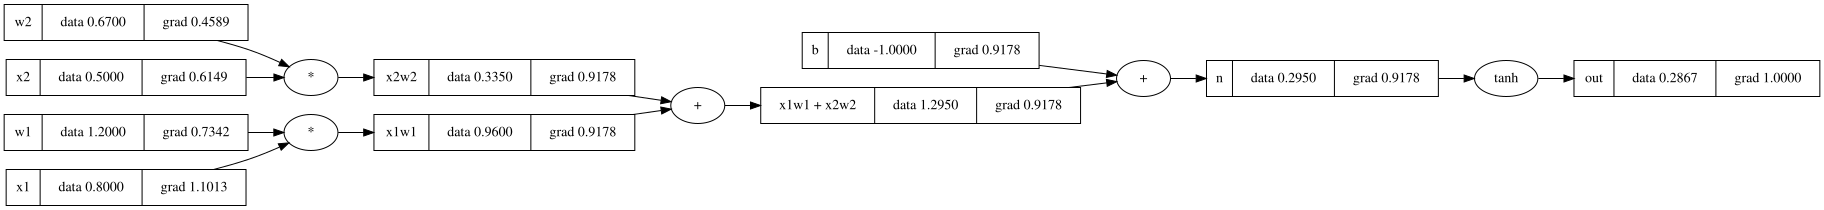

In [22]:
out.backward()
draw_dot(out)

In [23]:
# out.grad=1.0
# out._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# out.backward()



In [44]:
a=value(4)
b =a
print(b)

Value(data=4)


In [62]:
import torch

In [ ]:
class Neuron :
    def __init__(self , nin):
        self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = value(random.uniform(-1,1))

    def __call__(self , x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer():

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
    
class MLP():

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"
        
    
        

In [ ]:

nouts = [10,10,1]
mlp = MLP(1,nouts)
params = mlp.parameters()




# 1. CREATE A FIXED DATASET ONCE (Outside the epoch loop)
X_train = []
Y_train = []
for _ in range(50):
    raw_val = random.uniform(0, 50)
    X_train.append([raw_val / 50.0]) # Normalized input (0 to 1)
    Y_train.append((raw_val / 50.0)**2)   # Normalized target (0 to 1)

# Run for more epochs to watch it drop!
for j in range(200): 
    loss = value(0)
    
    # 2. LOOP OVER YOUR FIXED DATA
    for i in range(50):
        x = X_train[i]
        y_target = Y_train[i]
        
        output = mlp(x)
        
        # 3. COMPARE NORMALIZED TO NORMALIZED
        # Notice we are no longer multiplying output by 50
        loss += ((output - y_target)**2) * (0.02)

    loss = loss*20
        
    print(f"Epoch {j} loss: {loss.data}")

    for param in params:
        param.grad = 0
        
    loss.grad = 1
    loss.backward()
    
    # 4. Because our loss is now small and stable, we can safely 
    # raise the learning rate a bit without it exploding.
    for param in params:
        param.data += -0.04* param.grad



# for j in range(10):
#     loss=value(0)
#     for i in range(50):
#         x_raw=random.uniform(0,50)
#         x=[x_raw/50]
#         output = (mlp(x))
#         loss+=(((output*50)-x_raw)**2)*(0.02)
#     print(loss)

#     for param in params:
#         param.grad=0
#     loss.grad=1
#     loss.backward()
#     for param in params:
#         param.data += -0.2*(param.grad)












Epoch 0 loss: 6.476283849488929
Epoch 1 loss: 37.34472061200829
Epoch 2 loss: 37.34472061200829
Epoch 3 loss: 37.34472061200829
Epoch 4 loss: 37.34472061200828
Epoch 5 loss: 37.34472061200828
Epoch 6 loss: 37.34472061200828
Epoch 7 loss: 37.34472061200828
Epoch 8 loss: 37.34472061200828
Epoch 9 loss: 37.34472061200828
Epoch 10 loss: 37.34472061200828
Epoch 11 loss: 37.34472061200828
Epoch 12 loss: 37.34472061200828
Epoch 13 loss: 37.34472061200828
Epoch 14 loss: 37.34472061200828
Epoch 15 loss: 37.34472061200828
Epoch 16 loss: 37.34472061200828
Epoch 17 loss: 37.34472061200828
Epoch 18 loss: 37.34472061200828
Epoch 19 loss: 37.34472061200828
Epoch 20 loss: 37.34472061200828
Epoch 21 loss: 37.34472061200828
Epoch 22 loss: 37.34472061200828
Epoch 23 loss: 37.34472061200828
Epoch 24 loss: 37.34472061200828
Epoch 25 loss: 37.34472061200828
Epoch 26 loss: 37.34472061200828
Epoch 27 loss: 37.34472061200828
Epoch 28 loss: 37.34472061200828
Epoch 29 loss: 37.34472061200828
Epoch 30 loss: 37.34

In [ ]:
inp=[25]
out = mlp(inp)
print(out)

Value(data=0.7315938092379712)
